This notebook contains the Ridge regression and Random Forest models trained on the real-world data.

In [17]:
# load the data + imports

import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from pathlib import Path
import re
import matplotlib.pyplot as plt

# use this for real data
"""
df = pd.read_csv(
    "data/real_pruned/clip_alpha_0.000.csv",
    parse_dates=["timestamp"]
)

df = df.sort_values("timestamp").reset_index(drop=True)
"""
# use this for synthetic data
df = pd.read_csv(
    "data/synthetic_pruned/clip_alpha_0.000.csv",
    parse_dates=["timestamp"]
)

df = df.sort_values("timestamp").reset_index(drop=True)
# """

In [18]:
# enumerate datasets
# data_dir = Path("data/real_pruned")
data_dir = Path("data/synthetic_pruned")

files = sorted(data_dir.glob("clip_alpha_*.csv"))

# extract alpha from filename
def extract_alpha(path):
    return float((re.search(r"alpha_([0-9.]+)", path.name).group(1)).removesuffix("."))

datasets = [(extract_alpha(f), f) for f in files]
datasets

[(0.0, WindowsPath('data/synthetic_pruned/clip_alpha_0.000.csv')),
 (0.005, WindowsPath('data/synthetic_pruned/clip_alpha_0.005.csv')),
 (0.01, WindowsPath('data/synthetic_pruned/clip_alpha_0.010.csv')),
 (0.02, WindowsPath('data/synthetic_pruned/clip_alpha_0.020.csv')),
 (0.05, WindowsPath('data/synthetic_pruned/clip_alpha_0.050.csv'))]

In [19]:
def model_ridge():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=1.0))
    ])

def model_rf():
    return RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1,
        max_features="sqrt"
    )

In [ ]:
def evaluate_dataset(path, model, split_frac=0.8):
    df = pd.read_csv(path, parse_dates=["timestamp"])
    df = df.sort_values("timestamp").reset_index(drop=True)

    # log transforms
    df["log_pm2.5"] = np.log1p(df["pm2.5"])
    df["log_Iws"] = np.log1p(df["Iws"])
    df["log_Is"]  = np.log1p(df["Is"])
    df["log_Ir"]  = np.log1p(df["Ir"])

    features = [
        "DEWP", "TEMP", "PRES",
        "log_Iws", "log_Is", "log_Ir",
        "cbwd"
    ]

    X = df[features]
    y = df["log_pm2.5"]

    X = pd.get_dummies(X, columns=["cbwd"], drop_first=True)

    split = int(split_frac * len(df))
    X_train, X_test = X.iloc[:split], X.iloc[split:]
    y_train, y_test = y.iloc[:split], y.iloc[split:]

    model.fit(X_train, y_train)

    y_pred_log = model.predict(X_test)

    # metrics
    mae_log  = mean_absolute_error(y_test, y_pred_log)
    rmse_log = mean_squared_error(y_test, y_pred_log)

    y_test_raw = np.expm1(y_test)
    y_pred_raw = np.expm1(y_pred_log)

    mae_raw  = mean_absolute_error(y_test_raw, y_pred_raw)
    rmse_raw = mean_squared_error(y_test_raw, y_pred_raw)

    return {
        "mae_log": mae_log,
        "rmse_log": rmse_log,
        "mae_raw": mae_raw,
        "rmse_raw": rmse_raw,
    }

In [21]:
results = []

for alpha, path in datasets:
    for name, model in {
        "ridge": model_ridge(),
        "rf": model_rf()
    }.items():
        metrics = evaluate_dataset(path, model)
        metrics["alpha"] = alpha
        metrics["model"] = name
        results.append(metrics)

results_df = pd.DataFrame(results)

In [22]:
# results_df: columns = alpha, model, mae_raw, rmse_raw, mae_log, rmse_log

pivot = results_df.pivot(index="alpha", columns="model", values=["mae_raw", "rmse_raw", "mae_log", "rmse_log"])
pivot

mae_raw                rmse_raw                mae_log            \
model         rf      ridge           rf        ridge        rf     ridge   
alpha                                                                       
0.000  52.651879  52.266083  6400.730755  6264.959243  0.686000  0.680467   
0.005  52.605530  52.276308  6397.185173  6267.293866  0.685655  0.680616   
0.010  52.654785  52.293961  6411.410095  6273.557680  0.685829  0.680856   
0.020  52.715171  52.358725  6414.813144  6283.403746  0.686562  0.681890   
0.050  52.874255  52.567113  6435.083815  6318.508906  0.689283  0.685197   

       rmse_log            
model        rf     ridge  
alpha                      
0.000  0.752619  0.736513  
0.005  0.752558  0.736986  
0.010  0.752842  0.737763  
0.020  0.754745  0.739874  
0.050  0.759885  0.746714

In [23]:

def plot_metric_vs_alpha(df, metric, title, ylabel):
    plt.figure(figsize=(7, 4))
    
    styles = {
        "rf": {"color": "black", "linestyle": "-", "marker": "o"},
        "ridge": {"color": "dimgray", "linestyle": "--", "marker": "s"}
    }
    
    label_map = {
        "rf": "Random Forest",
        "ridge": "Ridge Regression"
    }
    
    for model_name, g in df.groupby("model"):
        g = g.sort_values("alpha")
        style = styles.get(model_name, {"color": "gray", "linestyle": "-", "marker": "o"})
        pretty_label = label_map.get(model_name, model_name)
        
        plt.plot(
            g["alpha"],
            g[metric],
            label=pretty_label,
            color=style["color"],
            linestyle=style["linestyle"],
            marker=style["marker"],
            markersize=5,
            linewidth=1.8
        )
    
    plt.xlabel("Clipping strength (α)")
    plt.ylabel(ylabel)
    plt.title(title)
    
    plt.grid(True, linestyle=":", linewidth=0.6, alpha=0.7)
    plt.legend(frameon=False)
    
    plt.tight_layout()
    plt.show()

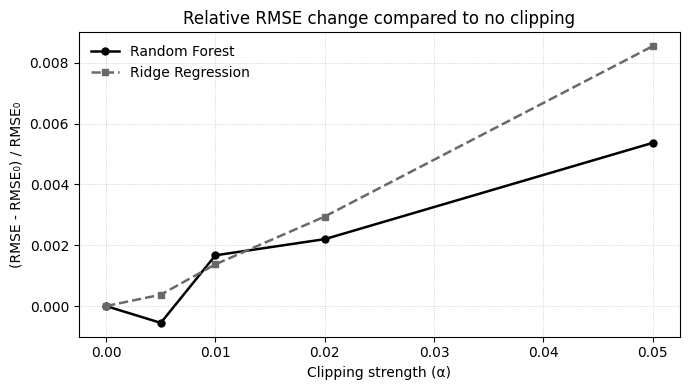

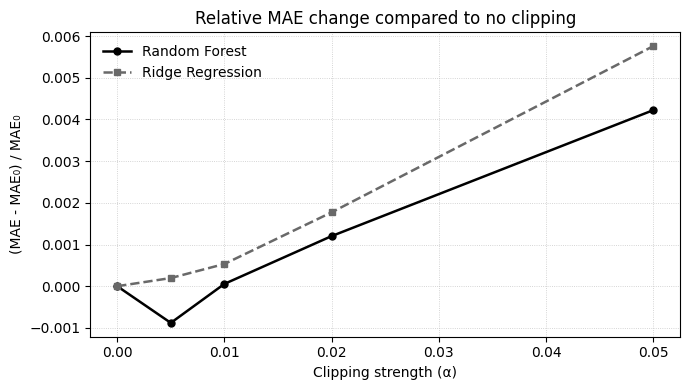

rmse_raw_rel           mae_raw_rel          
model           rf     ridge          rf     ridge
alpha                                             
0.000     0.000000  0.000000    0.000000  0.000000
0.005    -0.000554  0.000373   -0.000880  0.000196
0.010     0.001668  0.001372    0.000055  0.000533
0.020     0.002200  0.002944    0.001202  0.001772
0.050     0.005367  0.008547    0.004224  0.005760

In [24]:
def add_relative_change(df, metric):
    df = df.copy()
    base = df[df["alpha"] == 0.0].set_index("model")[metric]
    df[f"{metric}_rel"] = df.apply(
        lambda r: (r[metric] - base.loc[r["model"]]) / base.loc[r["model"]],
        axis=1
    )
    return df

rel_df = add_relative_change(results_df, "rmse_raw")
rel_df = add_relative_change(rel_df, "mae_raw")

plot_metric_vs_alpha(
    rel_df,
    metric="rmse_raw_rel",
    title="Relative RMSE change compared to no clipping",
    ylabel="(RMSE - RMSE₀) / RMSE₀"
)

plot_metric_vs_alpha(
    rel_df,
    metric="mae_raw_rel",
    title="Relative MAE change compared to no clipping",
    ylabel="(MAE - MAE₀) / MAE₀"
)

pivot = rel_df.pivot(index="alpha", columns="model", values=["rmse_raw_rel", "mae_raw_rel"])
pivot